In [1]:
# # m_small = 4*np.pi*rho_0*(h**3)
# # print(m_small)

# # m_large = rho_0*(np.pi*h*R)**(3/2)*2**(0.5)

    

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
R = 6378 # radius earth [km]
M_planet = 5.98e24 # mass earth [kg]
h = 8.5 # scaleheight earth [km]
M_atm = 5.15e18 # earth atmosphere mass [kg]
rho_0 = 1.293e9 # density at earth surface [kg/km^3]
# rho = 5.51e12 # density of earth [kg/km^3]
rho = 2e12


In [4]:
r_min = r_min = (3*rho_0/rho)**(1/3)*h # minimum impact size [km] ~ 1 km

r_cap = (3*np.sqrt(2*np.pi)*rho_0 / (4*rho))**(1/3) * (h*R)**(1/2) # cap size [km] ~ 25 km

r_gi = (2 * h * (R**2))**(1/3) # where giant impacts dominate [km]


# print(r_gi) # print giant impact mass, should be ~900 km

r = np.geomspace((r_min + 0.00001),3000,1000) # set up x-axis scale (log)
# print(r)


In [5]:
def M_T(r, r_min, r_cap, R, h, M_atm, M_planet, rho):
    """Calculate total impactor mass for different sized impactors"""
    r_gi = (2 * h * (R**2))**(1/3)
    
    
    if r <= r_cap:
        
        M_T = (2*r / r_min) * (1 - (r_min/r)**2)**(-1) * M_atm
        
    elif r_cap <= r <= r_gi:
        M_T = (4*np.pi/3) * rho * r**3 * (2*R/h)
        
    elif r > r_gi:
        M_T = 4 * M_planet
        
    MT_Mplanet = M_T / M_planet
    
    return MT_Mplanet



In [6]:
MT_Mp = [M_T(_, r_min, r_cap, R, h, M_atm, M_planet, rho) for _ in r]
MT_Mp = np.array(MT_Mp)


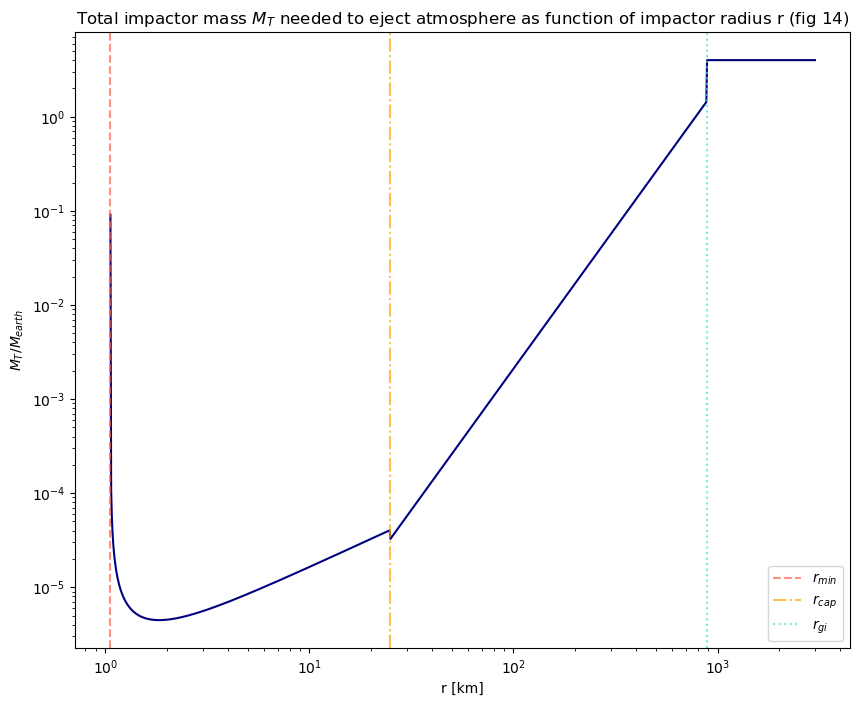

In [7]:
plt.figure(figsize=(10,8))
plt.plot(r, MT_Mp, color='navy')
plt.xlabel('r [km]')
plt.axvline(r_min, label=r'$r_{min}$', color='tomato', linestyle='--', alpha=0.7)
plt.axvline(r_cap, label=r'$r_{cap}$', color='orange', linestyle='-.', alpha=0.7)
plt.axvline(r_gi,label=r'$r_{gi}$' , color='turquoise', linestyle=':', alpha=0.7)
plt.ylabel(r'$M_T/M_{earth}$')
plt.title(r'Total impactor mass $M_T$ needed to eject atmosphere as function of impactor radius r (fig 14)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
# plt.savefig('Mtotal_vs_impactor_rad')
plt.show()
